In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/student_performance (1).csv")
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [14]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  str    
dtypes: float64(4), int64(1), str(1)
memory usage: 45.8 MB


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,15.029127,84.711046,5.985203,84.283845
std,288675.278932,6.899431,9.424143,1.956421,15.432969
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,250000.750000,10.300000,78.300000,4.700000,73.900000
50%,500000.500000,15.000000,85.000000,6.000000,87.500000
75%,750000.250000,19.700000,91.800000,7.300000,100.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000


In [15]:
df.isnull().sum()
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [16]:
df.isnull().sum()

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

In [17]:
df.drop("student_id", axis=1, inplace=True)

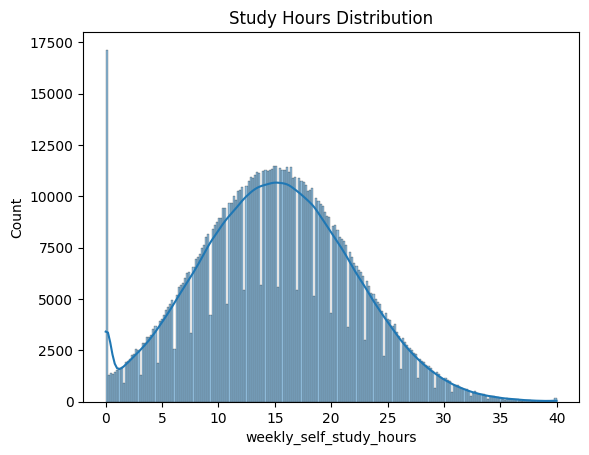

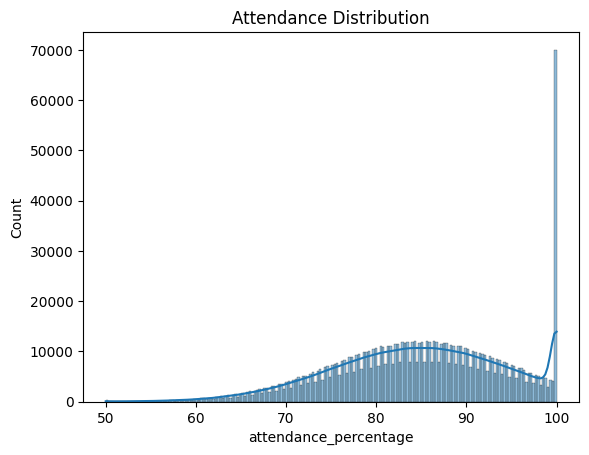

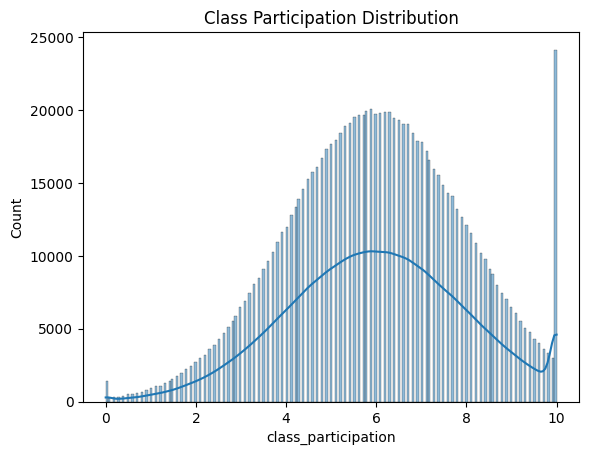

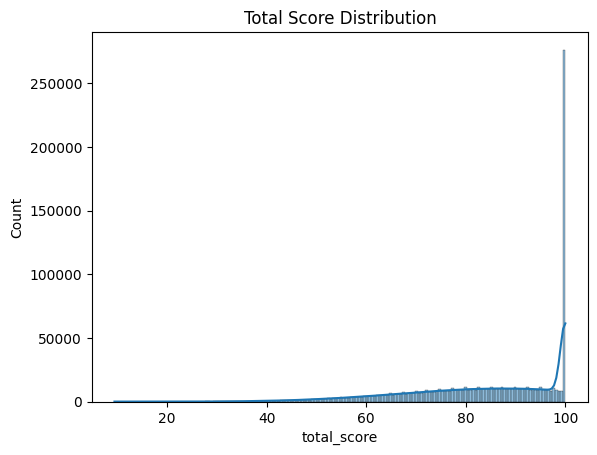

In [18]:
#EDA
#histplot of weekly_study_hours
sns.histplot(df["weekly_self_study_hours"], kde=True)
plt.title("Study Hours Distribution")
plt.show()

#hisplot of attendance_percentage
sns.histplot(df["attendance_percentage"], kde=True)
plt.title("Attendance Distribution")
plt.show()

#hisplot of class_participation_score
sns.histplot(df["class_participation"], kde=True)
plt.title("Class Participation Distribution")
plt.show()

#hisplot of total_score
sns.histplot(df["total_score"], kde=True)
plt.title("Total Score Distribution")
plt.show()

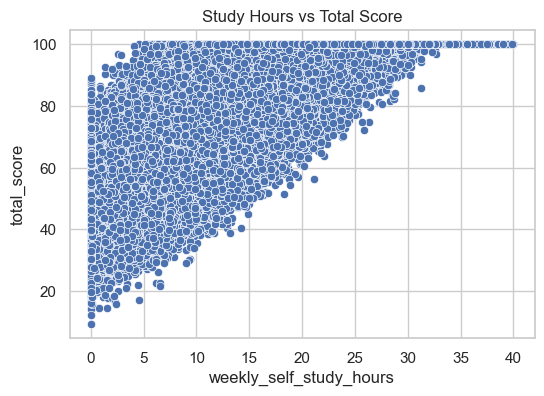

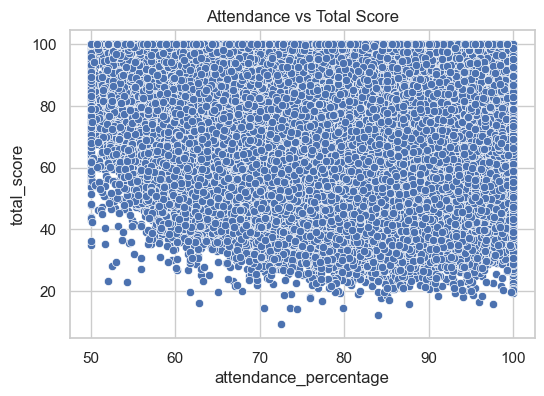

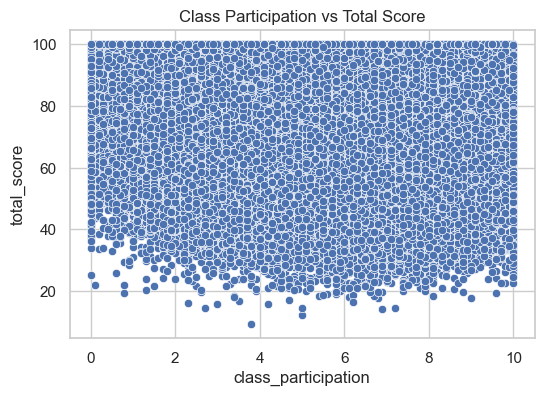

In [24]:
#Relationship Analysis
#Study Hours vs Score
plt.figure(figsize=(6,4))
sns.scatterplot(x="weekly_self_study_hours", y="total_score", data=df)
plt.title("Study Hours vs Total Score")
plt.show()

#Attendance vs Score
plt.figure(figsize=(6,4))
sns.scatterplot(x="attendance_percentage", y="total_score", data=df)
plt.title("Attendance vs Total Score")
plt.show()

#Class Participation vs Score
plt.figure(figsize=(6,4))
sns.scatterplot(x="class_participation", y="total_score", data=df)
plt.title("Class Participation vs Total Score")
plt.show()

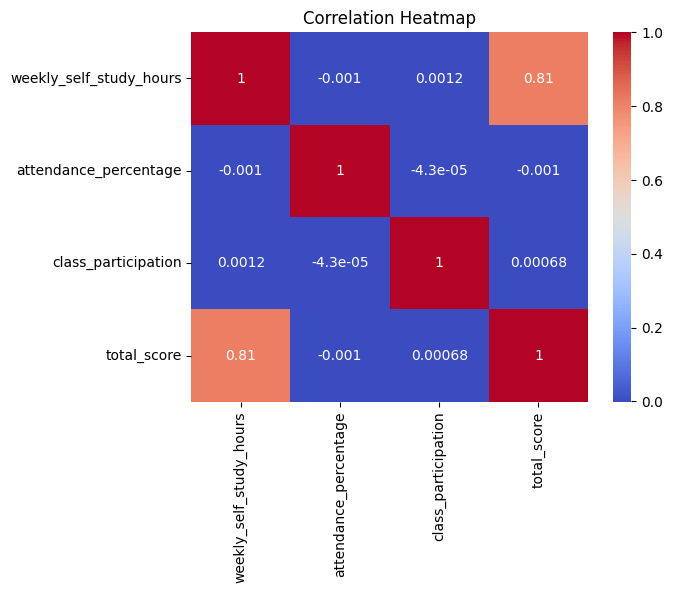

In [21]:
# Correlation heatmap
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

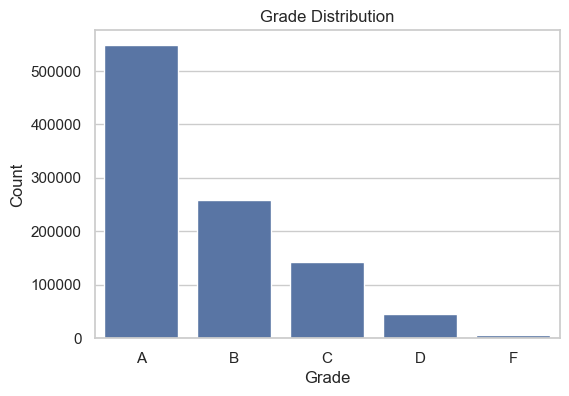

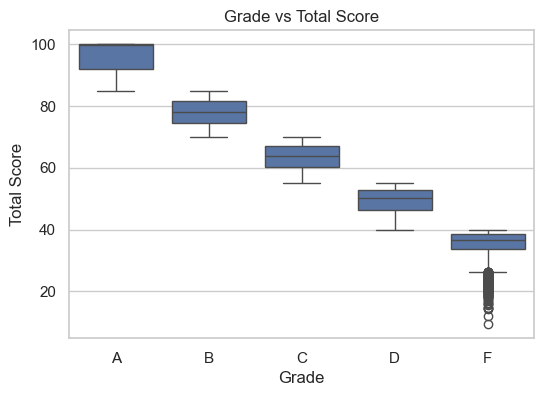

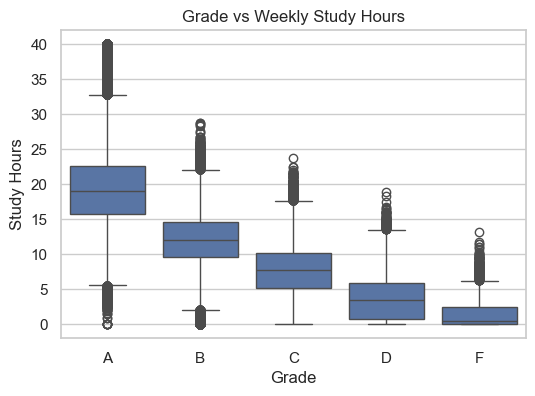

In [23]:
#Grade Analysis

# Set style
sns.set(style="whitegrid")

#Grade Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="grade", data=df)
plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.show()

#Grade vs Score
plt.figure(figsize=(6,4))
sns.boxplot(x="grade", y="total_score", data=df)
plt.title("Grade vs Total Score")
plt.xlabel("Grade")
plt.ylabel("Total Score")
plt.show()

#Study Hours vs Grade
plt.figure(figsize=(6,4))
sns.boxplot(x="grade", y="weekly_self_study_hours", data=df)
plt.title("Grade vs Weekly Study Hours")
plt.xlabel("Grade")
plt.ylabel("Study Hours")
plt.show()

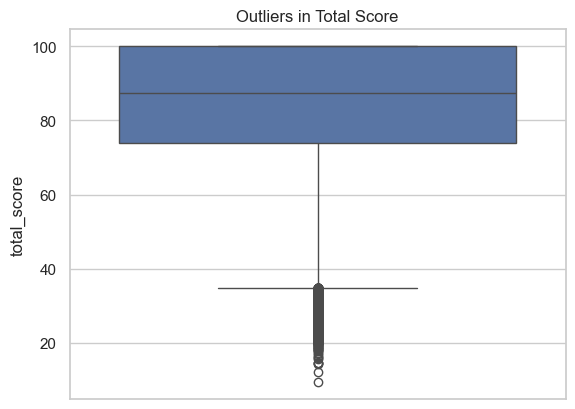

In [25]:
#Outliers Detection
sns.boxplot(df["total_score"])
plt.title("Outliers in Total Score")
plt.show()

In [26]:
#Feature Engineering
df["engagement"] = (
    df["weekly_self_study_hours"] +
    df["attendance_percentage"] +
    df["class_participation"]
) / 3